# 🏦 Gamified Simulation for Liquidity Risk Management During Market Stress


---

## 🎯 What Will We Learn?
- What **liquidity risk** means in simple terms
- How to simulate **bank stress scenarios** with Python
- How to calculate **LCR**, funding gaps, and cash reserves
- How to **visualize** financial crises with charts

---

## 💡 Key Concept: What Is Liquidity Risk?

> **Liquidity Risk** = The risk that you can't turn assets into cash fast enough when you need to pay someone.

**Simple Example:** You have $10,000 in a savings account and $200,000 in a house. If you need $50,000 tomorrow for an emergency, your house is not liquid — you can't sell it that fast. That's liquidity risk!

For banks, this gets much more serious. Let's simulate it! 🎮

## Step 1: Import Libraries 📦

We use basic Python libraries that any beginner can learn:

In [1]:
# Import all the libraries we need
import numpy as np          # For math and random numbers
import pandas as pd         # For data tables
import matplotlib.pyplot as plt  # For charts
import seaborn as sns       # For pretty charts
import warnings
warnings.filterwarnings('ignore')

# Make charts display inline in the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## Step 2: Load the Simulation Code 🔧

We import all our simulation functions from `simulation.py`

In [2]:
# Load the simulation module
# Make sure simulation.py is in the same folder as this notebook!
from simulation import (
    setup_bank,
    calculate_lcr,
    calculate_funding_gap,
    calculate_cash_reserve_ratio,
    scenario_bank_run,
    scenario_margin_call,
    scenario_fire_sale,
    scenario_funding_crisis,
    plot_cash_levels,
    plot_lcr_over_time,
    plot_scenario_comparison,
    plot_cash_flow_projection,
    plot_stress_test_summary,
    plot_heat_map,
    run_all_scenarios
)

print('✅ Simulation functions loaded!')

✅ Simulation functions loaded!


## Step 3: Set Up Our Bank 🏦

We create a fictional bank with starting values.
Think of this as choosing your character stats in a game!

In [3]:
# Set up the bank — these are the starting stats
my_bank = setup_bank(
    initial_cash=500,         # $500 million cash on hand
    total_deposits=2000,      # $2 billion in customer deposits
    liquid_assets=800,        # $800 million in easily-sold assets
    short_term_funding=600,   # $600 million in short-term borrowing
    daily_inflow=50,          # $50 million daily cash coming in
    daily_outflow=45          # $45 million daily cash going out
)

  🏦  BANK SETUP COMPLETE — STARTING STATS
  cash                     : $   500.0M
  liquid_assets            : $   800.0M
  total_deposits           : $ 2,000.0M
  short_term_funding       : $   600.0M
  daily_inflow             : $    50.0M
  daily_outflow            : $    45.0M
  net_stable_funding       : $   680.0M


## Step 4: Understand Liquidity Metrics 📐

Before running scenarios, let's calculate our bank's current health:

In [4]:
# Calculate current liquidity metrics

# HQLA = High Quality Liquid Assets (cash + most of liquid assets)
hqla = my_bank['cash'] + my_bank['liquid_assets'] * 0.85

# Expected net cash outflows over 30 days (estimated)
net_outflows_30d = my_bank['daily_outflow'] * 30

# Calculate the 3 key metrics
lcr = calculate_lcr(hqla, net_outflows_30d)
funding_gap = calculate_funding_gap(
    my_bank['daily_inflow'] * 30,  # 30-day inflows
    my_bank['daily_outflow'] * 30  # 30-day outflows
)
crr = calculate_cash_reserve_ratio(my_bank['cash'], my_bank['total_deposits'])

print('📊 CURRENT BANK HEALTH CHECK')
print('=' * 40)
print(f'  HQLA (High Quality Assets): ${hqla:,.1f}M')
print(f'  LCR (should be >= 100%):    {lcr:.1f}%  {"✅" if lcr >= 100 else "❌"}')
print(f'  30-Day Funding Gap:         ${funding_gap:,.1f}M {"✅" if funding_gap >= 0 else "❌"}')
print(f'  Cash Reserve Ratio:         {crr:.1f}%')
print('=' * 40)

📊 CURRENT BANK HEALTH CHECK
  HQLA (High Quality Assets): $1,180.0M
  LCR (should be >= 100%):    87.4%  ❌
  30-Day Funding Gap:         $150.0M ✅
  Cash Reserve Ratio:         25.0%


## Step 5: Run Stress Scenarios 🚨

Now the fun part — let's run each crisis scenario!

### 🚨 Scenario 1: Bank Run
Customers panic and withdraw 10% of deposits every day.

In [5]:
# Run the Bank Run scenario
# Try changing withdrawal_rate to 0.20 for a more severe crisis!
df_bank_run = scenario_bank_run(
    bank=my_bank,
    withdrawal_rate=0.10,  # 10% of deposits withdrawn daily
    days=30
)

print('\n📋 First 5 days of data:')
print(df_bank_run[['Day', 'Cash ($M)', 'Remaining Deposits ($M)', 'LCR (%)']].head())


🚨 Running Bank Run Scenario — 10% daily withdrawals
  ✅ Day 1 Cash: $350.0M  →  Day 30 Cash: $427.2M

📋 First 5 days of data:
   Day  Cash ($M)  Remaining Deposits ($M)  LCR (%)
0    1      350.0                  1800.00    17.17
1    2      220.0                  1620.00    16.67
2    3      108.0                  1458.00    16.21
3    4       12.2                  1312.20    15.83
4    5        0.0                  1180.98    17.27


In [6]:
# 📉 Scenario 2: Margin Call
df_margin = scenario_margin_call(
    bank=my_bank,
    volatility=0.05,               # 5% daily market swings
    collateral_req_increase=0.20,  # 20% more collateral demanded
    days=30
)

# 🔥 Scenario 3: Fire Sale
df_fire = scenario_fire_sale(
    bank=my_bank,
    discount_rate=0.30,       # Sell assets at 30% below fair value
    forced_selling_pct=0.05,  # Sell 5% of assets per day
    days=30
)

# 💸 Scenario 4: Funding Crisis
df_funding = scenario_funding_crisis(
    bank=my_bank,
    funding_reduction_rate=0.08,  # 8% less funding available each day
    days=30
)

# Combine all scenarios
all_scenarios = [df_bank_run, df_margin, df_fire, df_funding]
print('\n✅ All 4 scenarios completed!')


📉 Running Margin Call Scenario — 5% volatility, 20% collateral increase
  ✅ Day 1 Cash: $502.0M  →  Day 30 Cash: $151.8M

🔥 Running Fire Sale Scenario — 30% discount, 5% assets sold daily
  ✅ Day 1 Cash: $533.0M  →  Day 30 Cash: $1089.8M

💸 Running Funding Crisis Scenario — 8% daily funding reduction
  ✅ Day 1 Cash: $550.0M  →  Day 30 Cash: $0.0M

✅ All 4 scenarios completed!


## Step 6: Visualize the Results 📊

Let's generate all the charts!

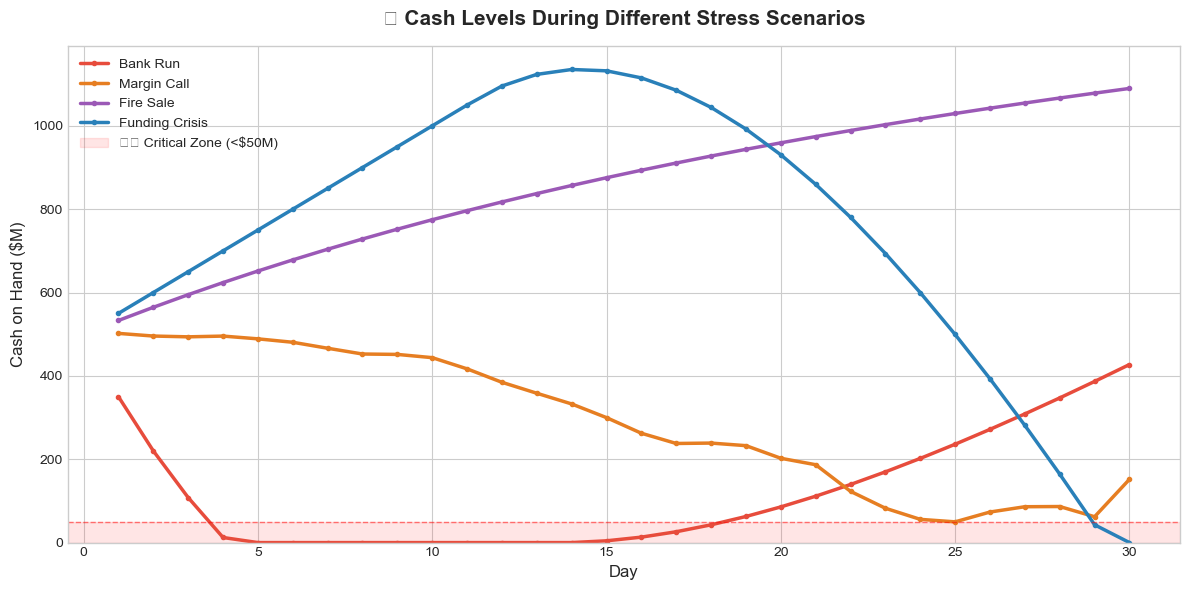

  📊 Chart saved: plots/cash_levels.png


In [8]:
# Chart 1: Cash levels comparison across all scenarios
plot_cash_levels(all_scenarios)

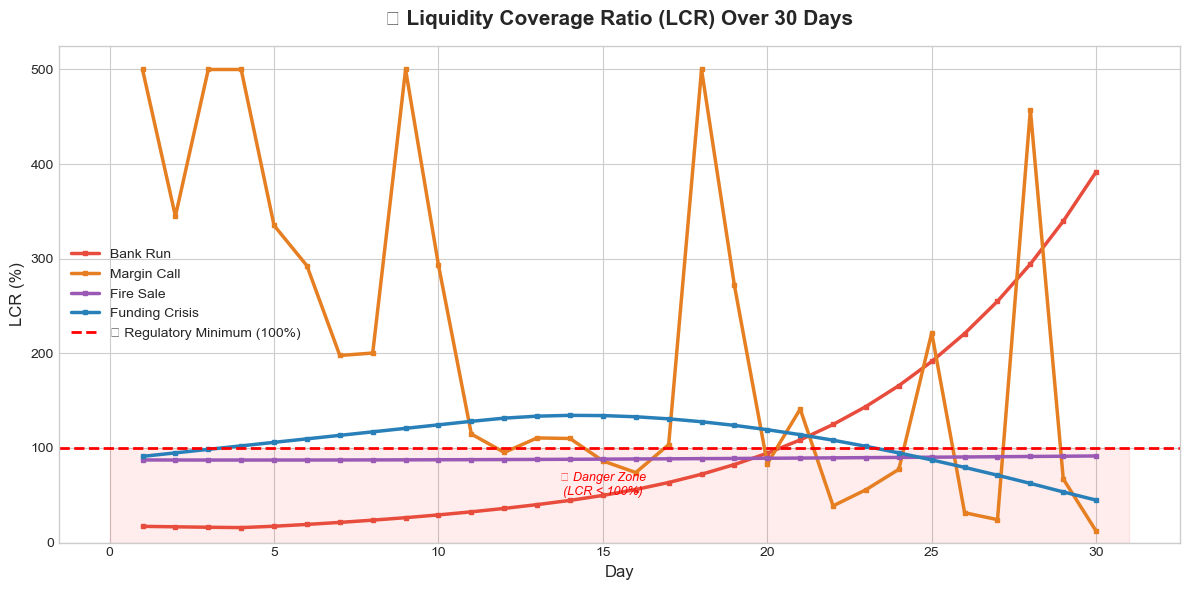

  📊 Chart saved: plots/lcr_over_time.png


In [9]:
# Chart 2: LCR over time — does the bank stay above 100%?
plot_lcr_over_time(all_scenarios)

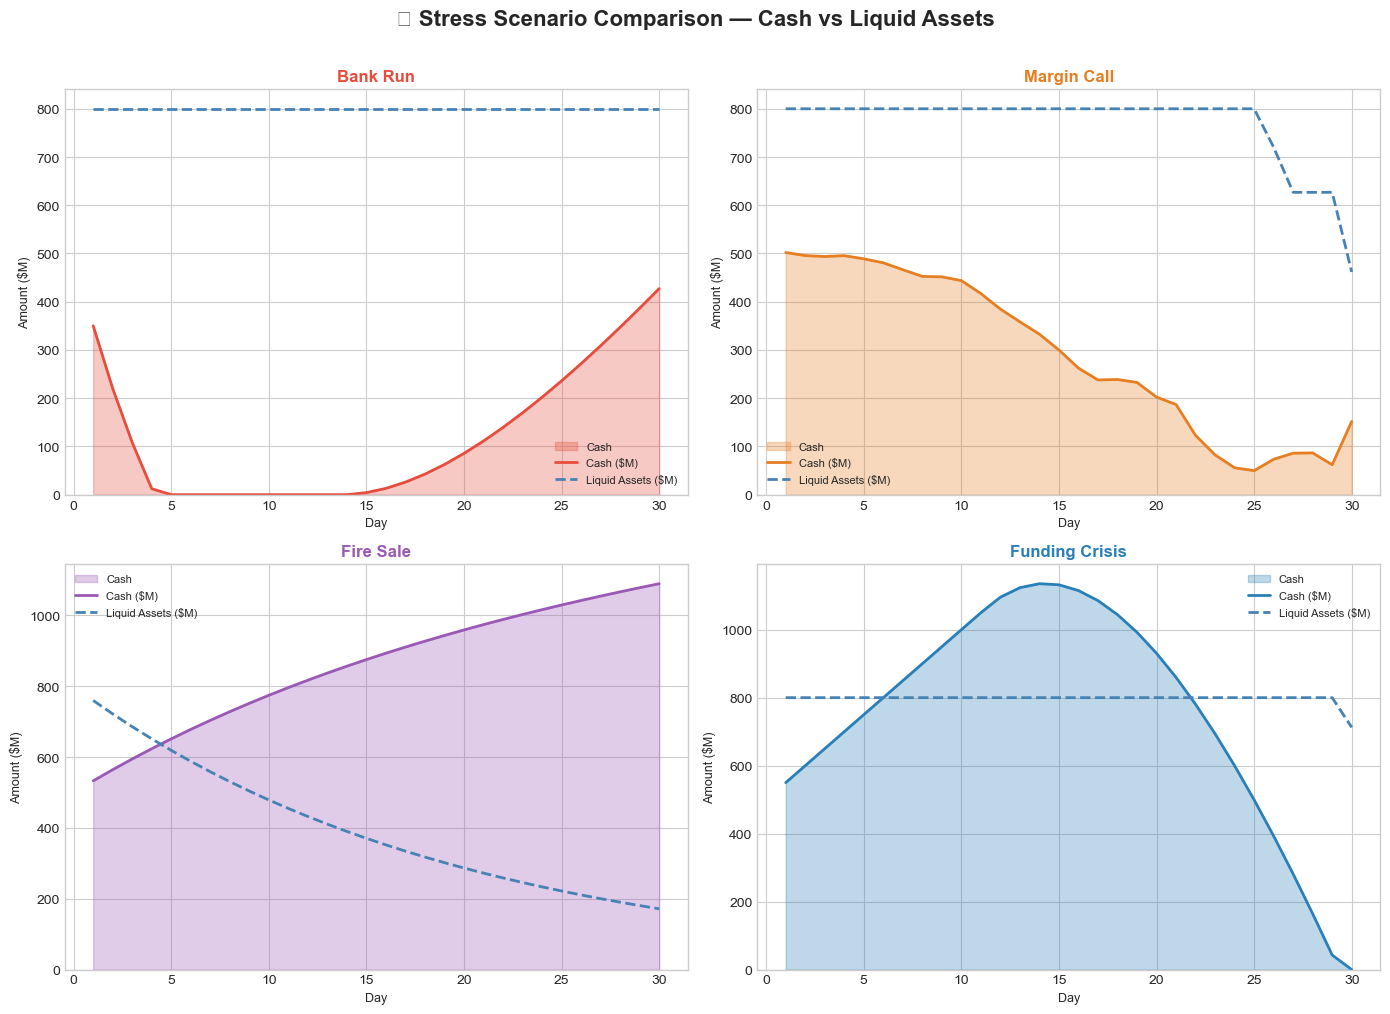

  📊 Chart saved: plots/scenario_comparison.png


In [10]:
# Chart 3: 2x2 side-by-side scenario comparison
plot_scenario_comparison(all_scenarios)

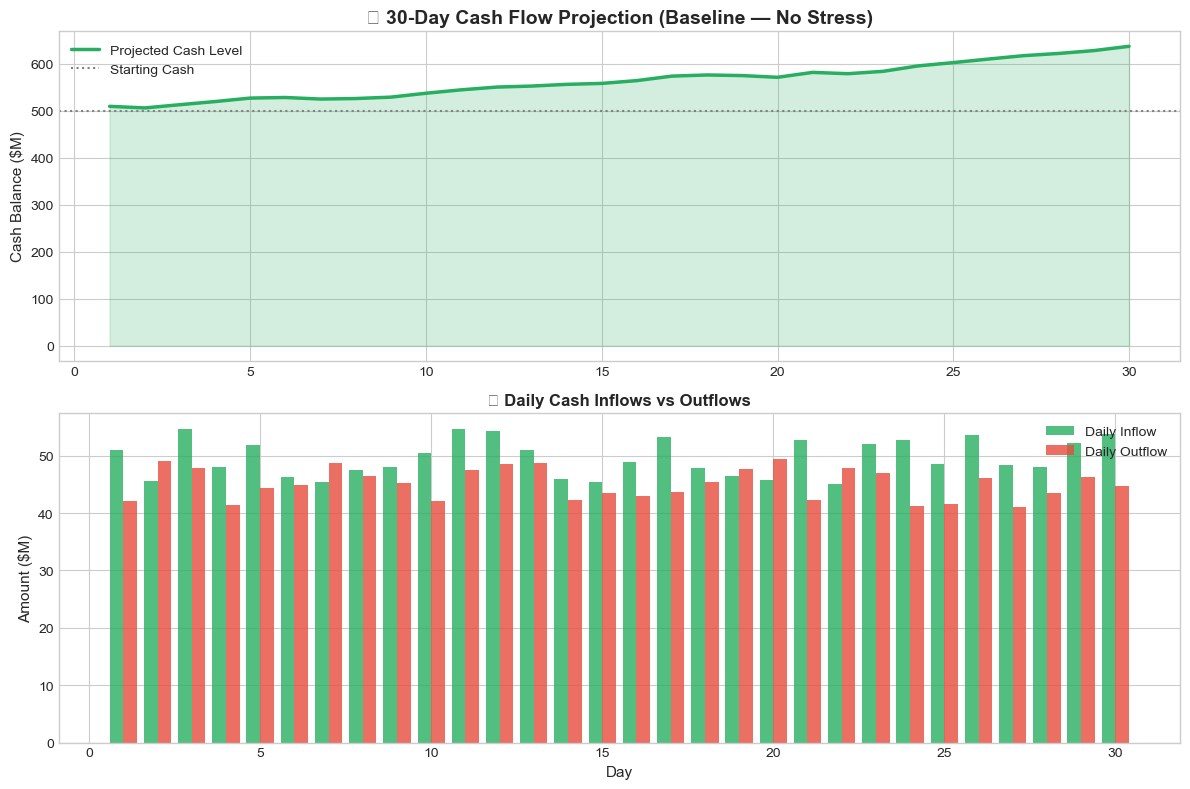

  📊 Chart saved: plots/cash_flow_projection.png


In [11]:
# Chart 4: Baseline 30-day cash flow projection (no stress)
plot_cash_flow_projection(my_bank, days=30)

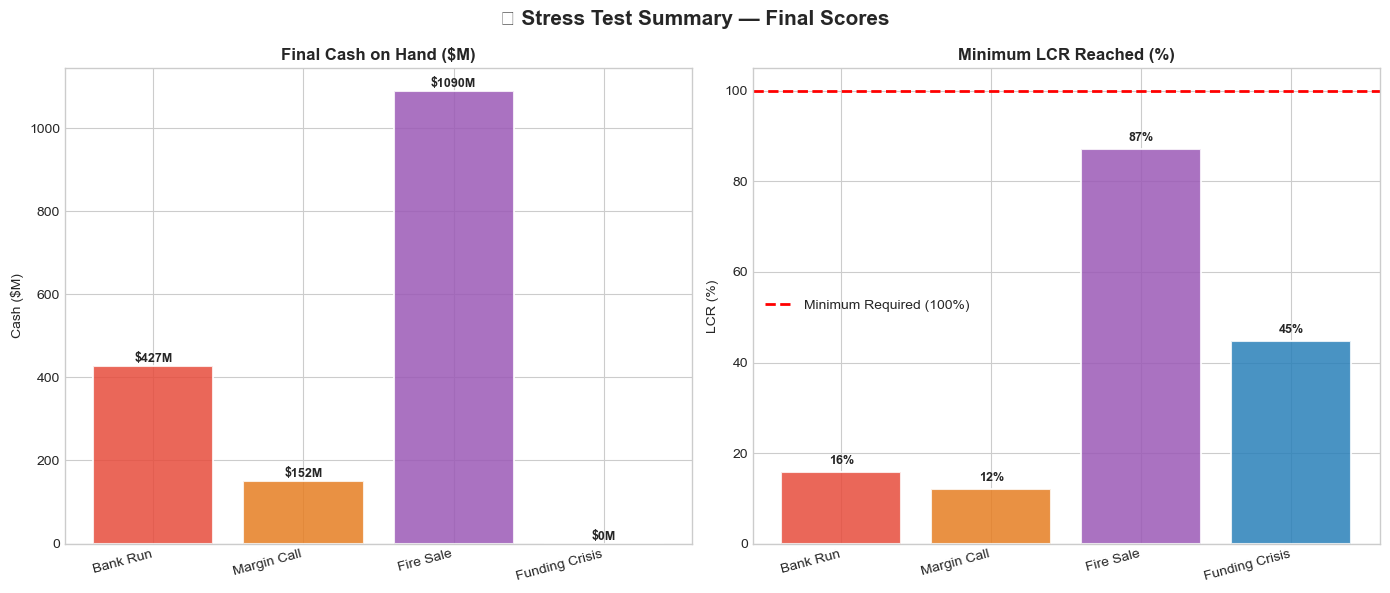

  📊 Chart saved: plots/stress_test_summary.png


In [12]:
# Chart 5: Stress test summary — final scores!
plot_stress_test_summary(all_scenarios)

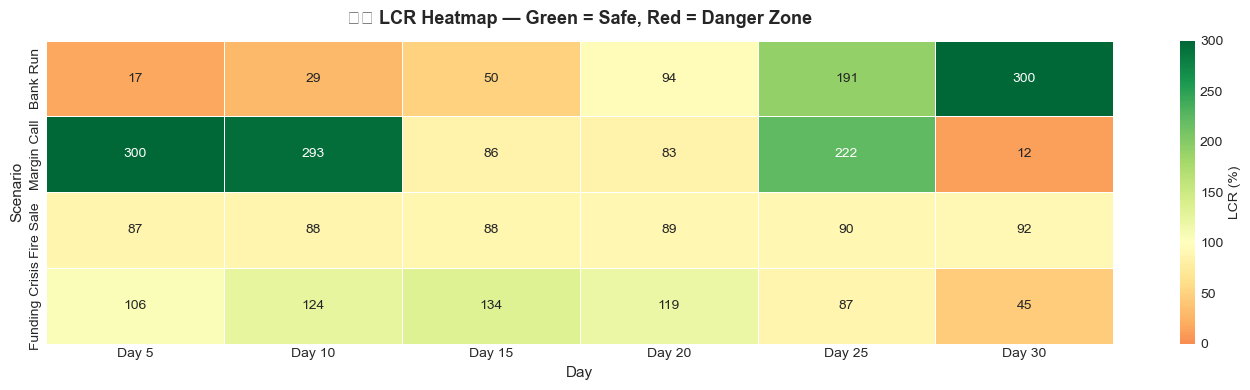

  📊 Chart saved: plots/heatmap_lcr.png


In [13]:
# Chart 6: LCR Heatmap — visual risk overview
plot_heat_map(all_scenarios)

## Step 7: Save & Explore the Data 💾

In [15]:
# Combine all scenarios into one DataFrame
combined_df = pd.concat(all_scenarios, ignore_index=True)
combined_df.to_csv('data/simulation_results.csv', index=False)

print(f'💾 Saved {len(combined_df)} rows to data/simulation_results.csv')
print('\n📋 Sample data:')
combined_df.groupby('Scenario')[['Cash ($M)', 'LCR (%)']].agg(['min', 'max', 'mean']).round(1)

💾 Saved 120 rows to data/simulation_results.csv

📋 Sample data:


Cash ($M)                LCR (%)               
                     min     max   mean     min     max   mean
Scenario                                                      
Bank Run             0.0   427.2  117.5    15.8   391.8  100.4
Fire Sale          533.0  1089.8  859.0    87.2    91.5   88.7
Funding Crisis       0.0  1135.3  758.9    44.9   134.5  106.4
Margin Call         49.8   502.0  289.8    12.1  1308.5  277.7

## 🎮 Step 8: PLAY WITH THE PARAMETERS!



  🎮  LIQUIDITY RISK SIMULATION STARTING...
  🏦  BANK SETUP COMPLETE — STARTING STATS
  cash                     : $   500.0M
  liquid_assets            : $   800.0M
  total_deposits           : $ 2,000.0M
  short_term_funding       : $   600.0M
  daily_inflow             : $    50.0M
  daily_outflow            : $    45.0M
  net_stable_funding       : $   680.0M

🚨 Running Bank Run Scenario — 10% daily withdrawals
  ✅ Day 1 Cash: $350.0M  →  Day 30 Cash: $427.2M

📉 Running Margin Call Scenario — 5% volatility, 20% collateral increase
  ✅ Day 1 Cash: $502.0M  →  Day 30 Cash: $151.8M

🔥 Running Fire Sale Scenario — 30% discount, 5% assets sold daily
  ✅ Day 1 Cash: $533.0M  →  Day 30 Cash: $1089.8M

💸 Running Funding Crisis Scenario — 8% daily funding reduction
  ✅ Day 1 Cash: $550.0M  →  Day 30 Cash: $0.0M

  📊  GENERATING VISUALIZATIONS...


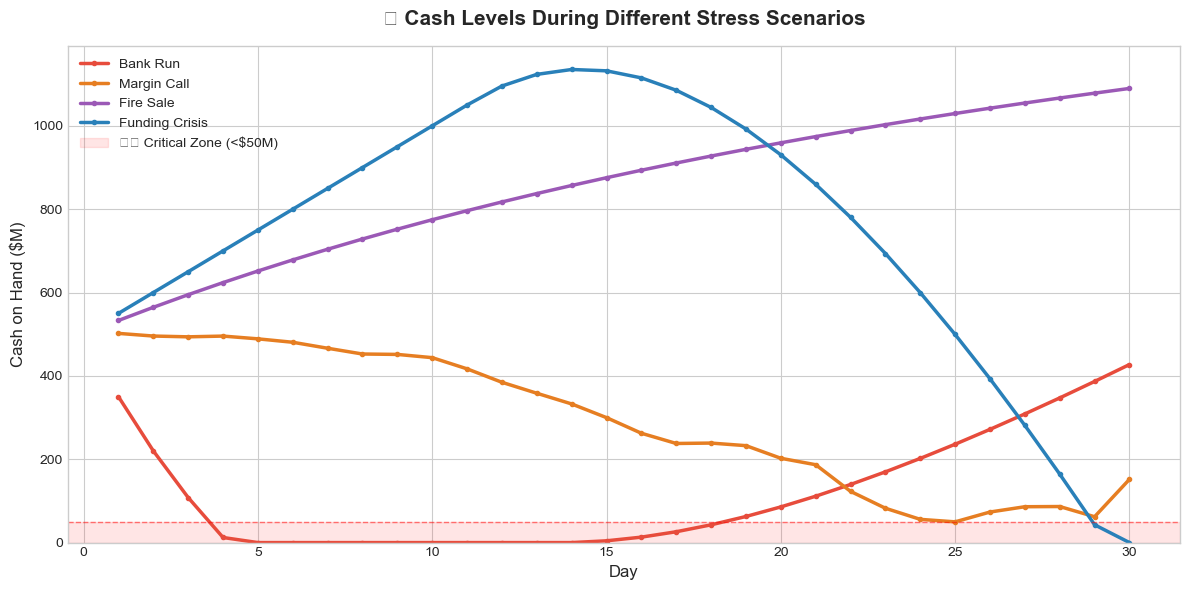

  📊 Chart saved: plots/cash_levels.png


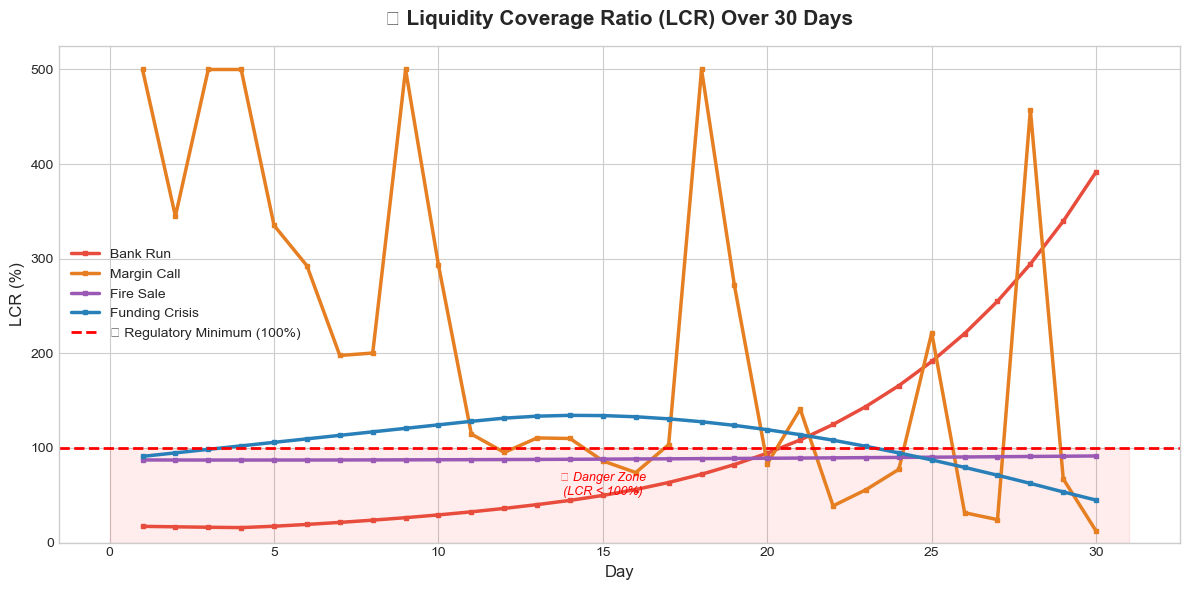

  📊 Chart saved: plots/lcr_over_time.png


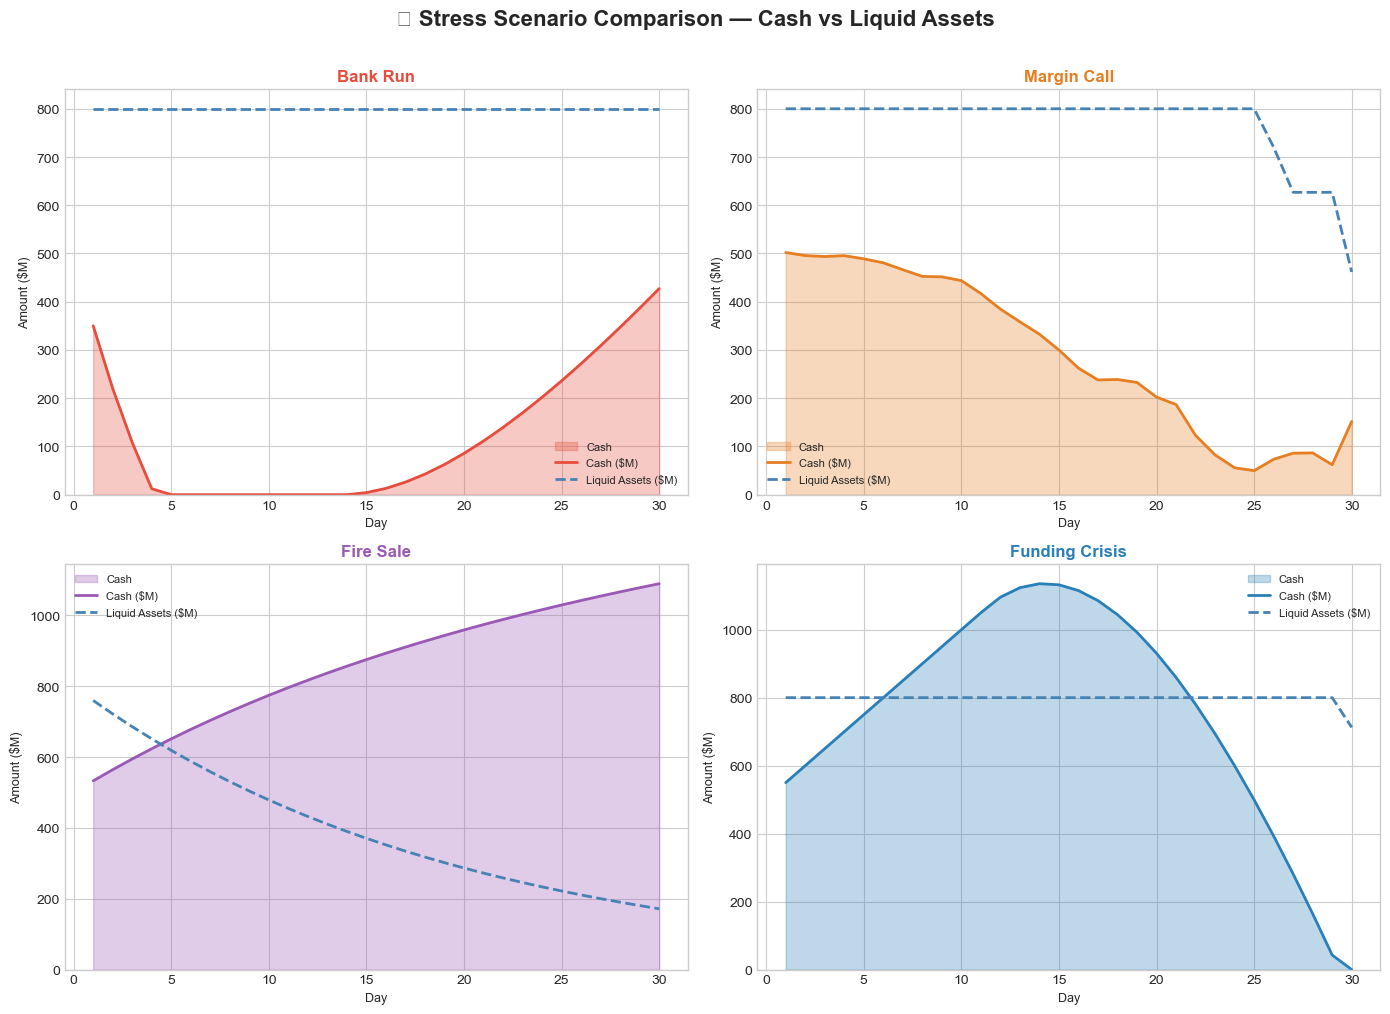

  📊 Chart saved: plots/scenario_comparison.png


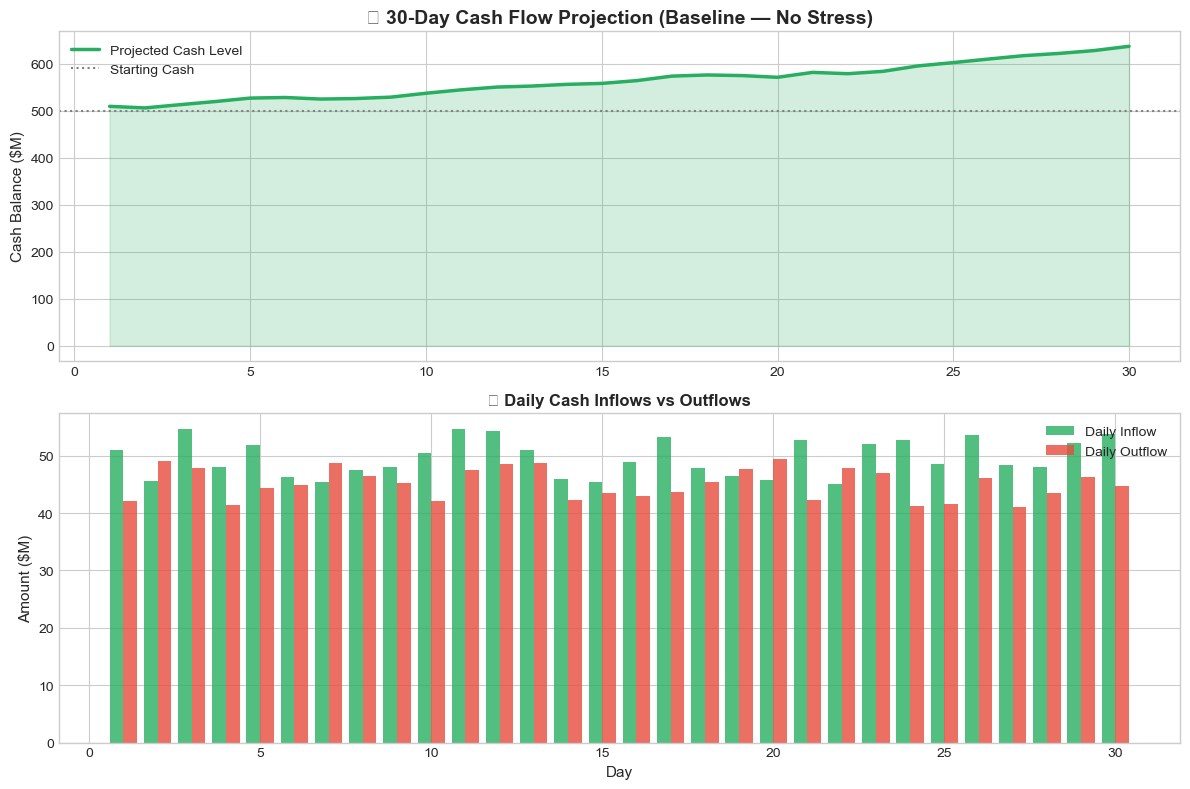

  📊 Chart saved: plots/cash_flow_projection.png


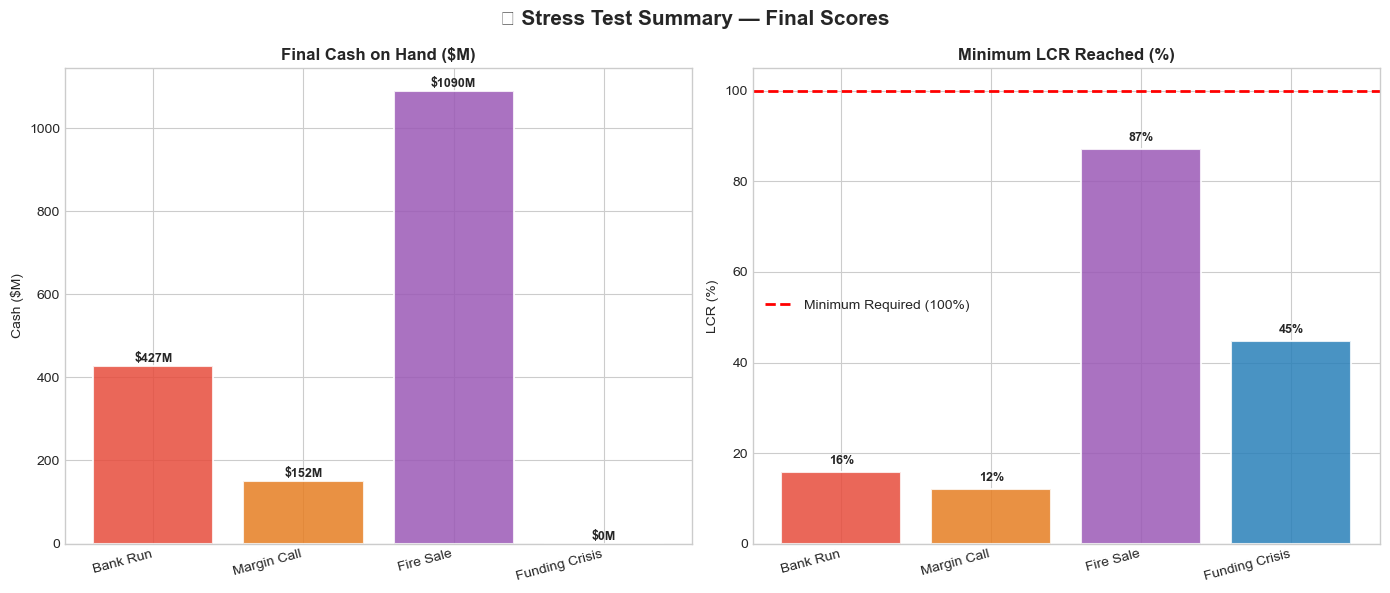

  📊 Chart saved: plots/stress_test_summary.png


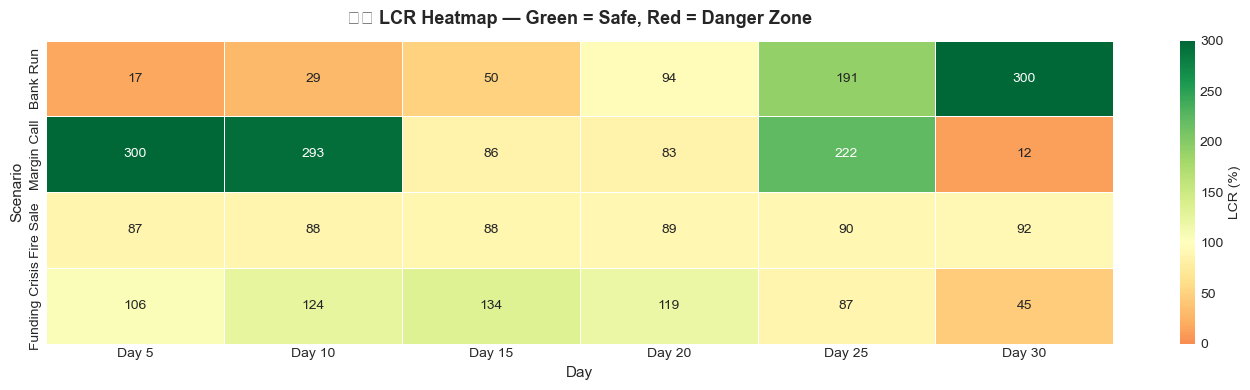

  📊 Chart saved: plots/heatmap_lcr.png

  💾 Data saved to: data/simulation_results.csv
     Shape: 120 rows × 13 columns

  📋  FINAL SUMMARY TABLE
  Bank Run           | Final Cash: $ 427.2M | Min LCR:   15.8% | ❌ FAILED LCR
  Margin Call        | Final Cash: $ 151.8M | Min LCR:   12.1% | ❌ FAILED LCR
  Fire Sale          | Final Cash: $1089.8M | Min LCR:   87.2% | ❌ FAILED LCR
  Funding Crisis     | Final Cash: $   0.0M | Min LCR:   44.9% | ❌ FAILED LCR


In [16]:
# ============================================
# 🎮 CHANGE THESE VALUES AND RE-RUN THIS CELL!
# ============================================

MY_WITHDRAWAL_RATE = 0.10     # Bank Run: try 0.05 (mild) to 0.25 (severe)
MY_VOLATILITY = 0.05          # Margin Call: try 0.02 (calm) to 0.15 (crash)
MY_DISCOUNT_RATE = 0.30       # Fire Sale: try 0.10 (small) to 0.60 (huge)
MY_FUNDING_REDUCTION = 0.08   # Funding: try 0.03 (slow) to 0.20 (fast)

# Run the full simulation with your parameters!
my_scenarios, my_data = run_all_scenarios(
    withdrawal_rate=MY_WITHDRAWAL_RATE,
    volatility=MY_VOLATILITY,
    discount_rate=MY_DISCOUNT_RATE,
    funding_reduction_rate=MY_FUNDING_REDUCTION,
    days=30
)

---

## ✅ Summary 

| Scenario | What Happened | Key Takeaway |
|---|---|---|
| **Bank Run** | Cash drained as deposits were withdrawn | Even healthy banks fail with mass panic |
| **Margin Call** | Collateral demands ate into cash reserves | Market volatility creates cascading costs |
| **Fire Sale** | Assets sold below fair value | Desperate selling destroys long-term value |
| **Funding Crisis** | Short-term funding disappeared | Relying on short-term funding is very risky |

### Key Metrics Learned:
- **LCR ≥ 100%** = Minimum safety threshold for banks
- **Funding Gap < 0** = The bank needs emergency cash
- **Cash Reserve Ratio** = How much cash is kept vs deposits

---